Importation et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# Chargement des données (CORRECTION)
train_df = pd.read_csv('training.csv')
val_df   = pd.read_csv('validation.csv')
test_df  = pd.read_csv('test.csv')

# Utiliser directement le label comme émotion (CORRECTION)
train_df['emotion'] = train_df['label']

# Vérification
print(f"Train size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")
print(f"Test size  : {len(test_df)}")

print(train_df.head())
print(train_df['emotion'].value_counts())

Train size : 16000
Val size   : 2000
Test size  : 2000
                                                text  label  emotion
0                            i didnt feel humiliated      0        0
1  i can go from feeling so hopeless to so damned...      0        0
2   im grabbing a minute to post i feel greedy wrong      3        3
3  i am ever feeling nostalgic about the fireplac...      2        2
4                               i am feeling grouchy      3        3
emotion
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64


Distribution des classes

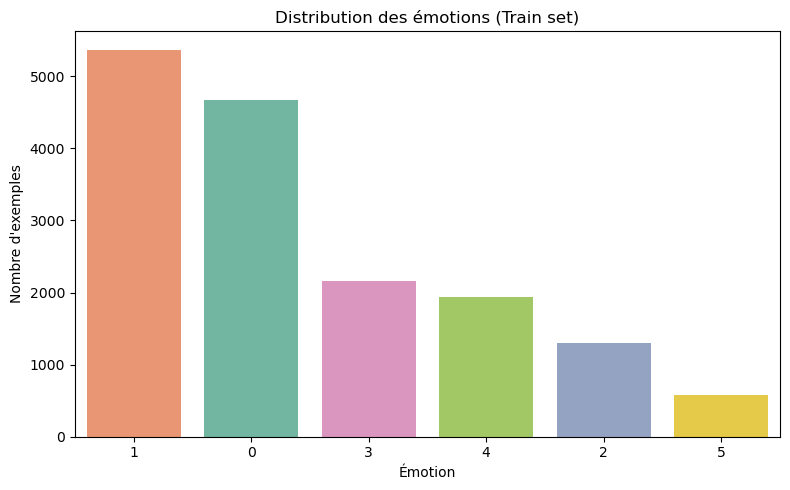

emotion
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64


In [2]:
plt.figure(figsize=(8, 5))

order = train_df['emotion'].value_counts().index

sns.countplot(
    data=train_df,
    x='emotion',
    order=order,
    hue='emotion',
    palette='Set2',
    legend=False
)

plt.title('Distribution des émotions (Train set)')
plt.xlabel('Émotion')
plt.ylabel("Nombre d'exemples")

plt.tight_layout()
plt.show()

print(train_df['emotion'].value_counts())

Longueur des textes

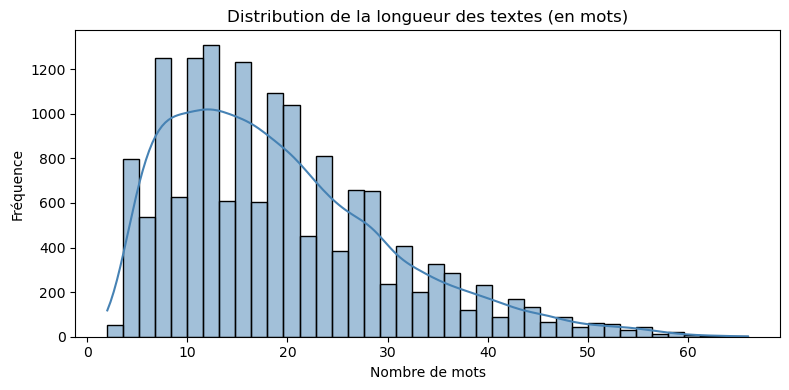

Longueur moyenne : 19.2 mots
Longueur max     : 66 mots
Longueur min     : 2 mots


In [3]:
train_df['text_length'] = train_df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
sns.histplot(train_df['text_length'], bins=40, kde=True, color='steelblue')
plt.title('Distribution de la longueur des textes (en mots)')
plt.xlabel('Nombre de mots')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

print(f"Longueur moyenne : {train_df['text_length'].mean():.1f} mots")
print(f"Longueur max     : {train_df['text_length'].max()} mots")
print(f"Longueur min     : {train_df['text_length'].min()} mots")

WordCloud par émotion

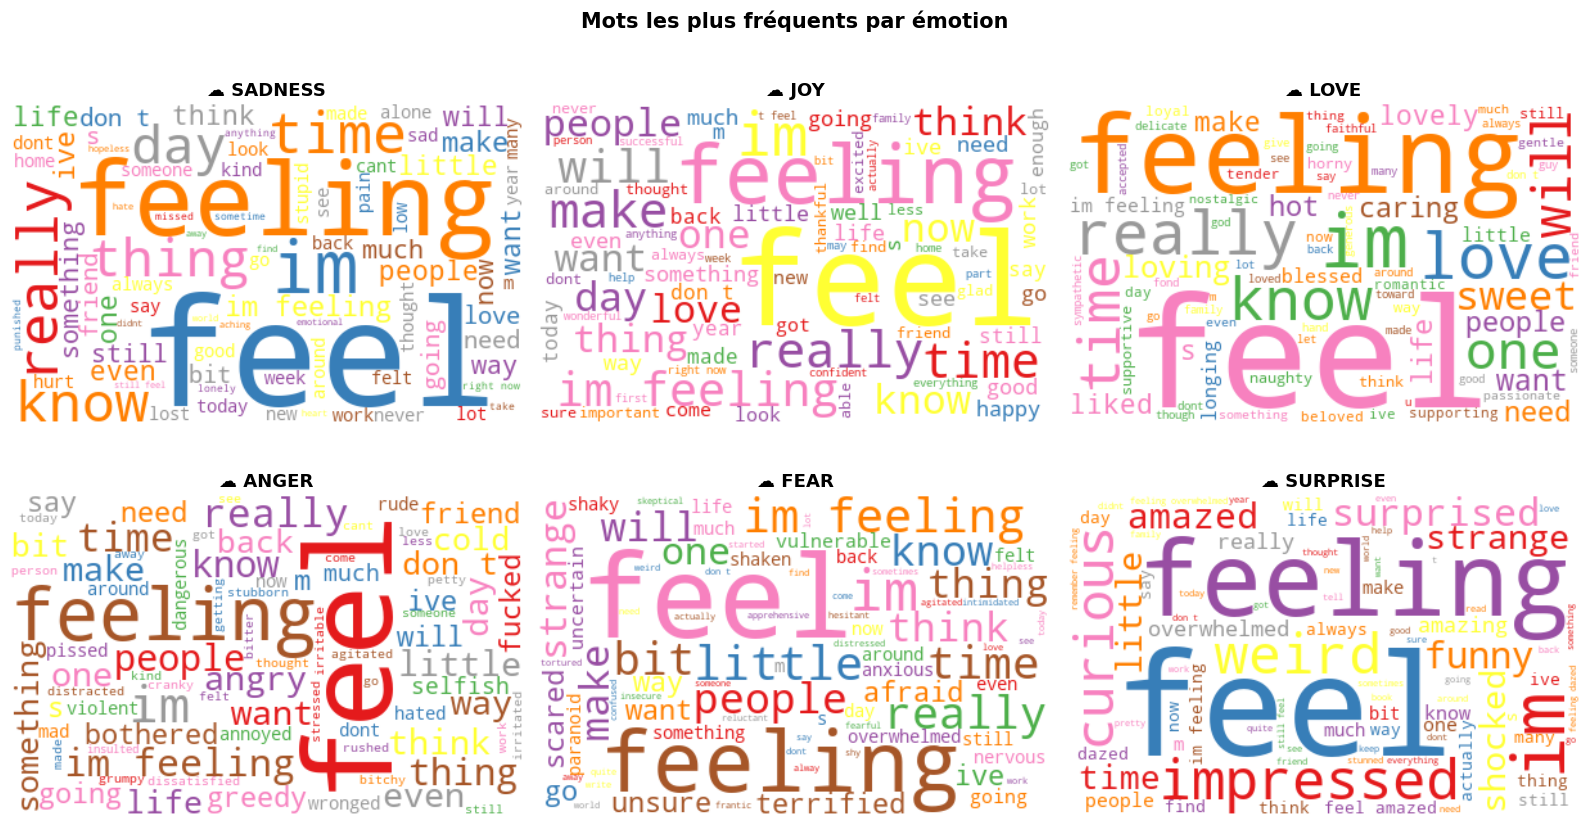

In [4]:
emotion_map = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

emotions = train_df['label'].unique()

for i, emotion in enumerate(sorted(emotions)):
    texts = ' '.join(train_df[train_df['label'] == emotion]['text'].tolist())
    
    if not texts.strip():
        axes[i].set_title(f'{emotion_map[emotion].upper()} (no data)', fontsize=13)
        axes[i].axis('off')
        continue
    
    wc = WordCloud(width=400, height=250,
                   background_color='white',
                   colormap='Set1',
                   max_words=80).generate(texts)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'☁️ {emotion_map[emotion].upper()}', fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Mots les plus fréquents par émotion', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

 Étape 3 — Pré-traitement des tweets

 Nettoyage des textes

In [26]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Stopwords NLTK de base — sans trop supprimer
stop_words = set(stopwords.words('english'))

# Garder les mots émotionnellement importants
# On retire de la liste stop les mots qui portent des émotions
emotional_keep = {
    'no', 'not', 'nor', 'never', 'neither', 'nobody', 'nothing',
    'nowhere', 'cannot', 'needn', 'shouldn', 'wouldn', 'couldn',
    'won', 'don', 'doesn', 'didn', 'hadn', 'hasn', 'haven',
    'very', 'too', 'so', 'really', 'quite', 'just', 'more',
    'most', 'less', 'least', 'few', 'little', 'much'
}
stop_words = stop_words - emotional_keep

# Supprimer SEULEMENT les mots vraiment non-informatifs
custom_remove = {'feel', 'feeling', 'im', 'ive', 'got', 'get',
                 'would', 'could', 'also', 'one', 'two', 'like',
                 'even', 'still', 'back', 'going', 'make', 'way'}
stop_words = stop_words.union(custom_remove)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # URLs
    text = re.sub(r'@\w+', '', text)                  # mentions
    text = re.sub(r'#(\w+)', r'\1', text)             # garder le mot du hashtag
    text = re.sub(r'[^a-z\s]', '', text)              # ponctuation
    words = text.split()
    # Garder les mots de longueur >= 2 qui ne sont pas stopwords
    words = [w for w in words if w not in stop_words and len(w) >= 2]
    text = ' '.join(words).strip()
    return text

# Appliquer sur les 3 splits
train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text']   = val_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

# Vérification — s'assurer qu'il n'y a pas de textes vides
empty_train = (train_df['clean_text'].str.strip() == '').sum()
empty_val   = (val_df['clean_text'].str.strip() == '').sum()
empty_test  = (test_df['clean_text'].str.strip() == '').sum()

print(train_df[['text', 'clean_text']].head(5))
print(f"\nTextes vides — train: {empty_train} | val: {empty_val} | test: {empty_test}")
print(f"Longueur moyenne après nettoyage : {train_df['clean_text'].apply(lambda x: len(x.split())).mean():.1f} mots")

                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                          clean_text  
0                                   didnt humiliated  
1  go so hopeless so damned hopeful just around s...  
2                  grabbing minute post greedy wrong  
3             ever nostalgic fireplace know property  
4                                            grouchy  

Textes vides — train: 0 | val: 0 | test: 0
Longueur moyenne après nettoyage : 8.2 mots


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Tokenisation + Padding

In [27]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN   = 50      # longueur max (décidé à l'EDA)
MAX_WORDS = 20000   # taille du vocabulaire

# Tokenizer — entraîné uniquement sur le train
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

# Conversion texte → séquences d'entiers
X_train = tokenizer.texts_to_sequences(train_df['clean_text'])
X_val   = tokenizer.texts_to_sequences(val_df['clean_text'])
X_test  = tokenizer.texts_to_sequences(test_df['clean_text'])

# Padding — toutes les séquences à la même longueur
X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(X_val,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')

# Labels
y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"Vocabulaire   : {len(tokenizer.word_index)} mots uniques")

X_train shape : (16000, 50)
X_val shape   : (2000, 50)
X_test shape  : (2000, 50)
Vocabulaire   : 15046 mots uniques


Class Weights (déséquilibre)

In [28]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced',
                                classes=classes,
                                y=y_train)

class_weight_dict = dict(zip(classes, weights))
print("Class weights :")
emotion_names = {0:'sadness', 1:'joy', 2:'love', 3:'anger', 4:'fear', 5:'surprise'}
for k, v in class_weight_dict.items():
    print(f"  {emotion_names[k]:10s} (label {k}) → {v:.4f}")

Class weights :
  sadness    (label 0) → 0.5715
  joy        (label 1) → 0.4973
  love       (label 2) → 2.0450
  anger      (label 3) → 1.2351
  fear       (label 4) → 1.3767
  surprise   (label 5) → 4.6620


🏗️ Étape 4 — Construction des Modèles

Bloc 8 — Imports & Paramètres globaux

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Conv1D, MaxPooling1D,
                                      Bidirectional, LSTM, Dense, Dropout,
                                      GlobalMaxPooling1D, Concatenate,
                                      LayerNormalization, Multiply, Activation,
                                      Flatten, Permute, RepeatVector, Lambda)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import keras.backend as K

# Paramètres globaux
VOCAB_SIZE  = 20000   # MAX_WORDS du tokenizer
EMBED_DIM   = 128     # dimension des embeddings
MAX_LEN     = 50      # longueur des séquences
NUM_CLASSES = 6       # 6 émotions

print("✅ Imports OK")
print(f"TensorFlow version : {tf.__version__}")

✅ Imports OK
TensorFlow version : 2.21.0


Bloc 9 — Modèle 1 : CNN (Baseline)

In [30]:
def build_cnn(vocab_size, embed_dim, max_len, num_classes):
    inputs = Input(shape=(max_len,))
    
    # Embedding
    x = Embedding(vocab_size, embed_dim, input_length=max_len)(inputs)
    
    # 3 filtres CNN en parallèle (tailles différentes)
    conv1 = Conv1D(128, kernel_size=2, activation='relu', padding='same')(x)
    conv1 = GlobalMaxPooling1D()(conv1)
    
    conv2 = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    conv2 = GlobalMaxPooling1D()(conv2)
    
    conv3 = Conv1D(128, kernel_size=4, activation='relu', padding='same')(x)
    conv3 = GlobalMaxPooling1D()(conv3)
    
    # Concatenation des 3 branches
    x = Concatenate()([conv1, conv2, conv3])
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    # Sortie
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name='CNN_Baseline')
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_cnn = build_cnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
model_cnn.summary()

C:\Users\moham\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 50)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_4 (Embedding)       │ (None, 50, 128)           │       2,560,000 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_11 (Conv1D)            │ (None, 50, 128)           │          32,896 │ embedding_4[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_12 (Conv1D)            │ (None, 50, 128)           │          49,280 │ embedding_4[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_13 (Conv1D)            │ (None, 50, 128)           │          65,664 │ embedding_4[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_6        │ (None, 128)               │               0 │ conv1d_11[0][0]            │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_7        │ (None, 128)               │               0 │ conv1d_12[0][0]            │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_8        │ (None, 128)               │               0 │ conv1d_13[0][0]            │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_3 (Concatenate)   │ (None, 384)               │               0 │ global_max_pooling1d_6[0]… │
│                               │                           │                 │ global_max_pooling1d_7[0]… │
│                               │                           │                 │ global_max_pooling1d_8[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_17 (Dropout)          │ (None, 384)               │               0 │ concatenate_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_11 (Dense)              │ (None, 128)               │          49,280 │ dropout_17[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_18 (Dropout)          │ (None, 128)               │               0 │ dense_11[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_12 (Dense)              │ (None, 6)                 │             774 │ dropout_18[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,757,894 (10.52 MB)

 Trainable params: 2,757,894 (10.52 MB)

 Non-trainable params: 0 (0.00 B)

Bloc 10 — Modèle 2 : BiLSTM

In [31]:
def build_bilstm(vocab_size, embed_dim, max_len, num_classes):
    inputs = Input(shape=(max_len,))
    
    # Embedding
    x = Embedding(vocab_size, embed_dim, input_length=max_len)(inputs)
    x = Dropout(0.3)(x)
    
    # BiLSTM empilés
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(64, return_sequences=False))(x)
    x = Dropout(0.3)(x)
    
    # Dense
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    # Sortie
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name='BiLSTM')
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_bilstm = build_bilstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
model_bilstm.summary()

C:\Users\moham\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_5 (Embedding)              │ (None, 50, 128)             │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 50, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 50, 256)             │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 50, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_5 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,004,806 (11.46 MB)

 Trainable params: 3,004,806 (11.46 MB)

 Non-trainable params: 0 (0.00 B)

Bloc 11 — Modèle 3 : CNN + BiLSTM + Attention 


In [32]:
from tensorflow.keras.layers import Layer
import tensorflow as tf

# Couche d'Attention personnalisée (compatible Keras 3)
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight',
                                  shape=(input_shape[-1], 1),
                                  initializer='glorot_uniform',
                                  trainable=True)
        self.b = self.add_weight(name='att_bias',
                                  shape=(1,),
                                  initializer='zeros',
                                  trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # Score d'attention
        score = tf.nn.tanh(tf.matmul(inputs, self.W) + self.b)  # (batch, steps, 1)
        attention_weights = tf.nn.softmax(score, axis=1)          # (batch, steps, 1)
        # Vecteur contexte
        context = inputs * attention_weights                       # (batch, steps, hidden)
        context = tf.reduce_sum(context, axis=1)                   # (batch, hidden)
        return context

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])


def build_cnn_bilstm_attention(vocab_size, embed_dim, max_len, num_classes):
    inputs = Input(shape=(max_len,))

    # 1. Embedding
    x = Embedding(vocab_size, embed_dim)(inputs)
    x = Dropout(0.3)(x)

    # 2. CNN — extraction de features locales
    x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    # 3. BiLSTM — capture des dépendances contextuelles
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    # 4. Attention 
    x = AttentionLayer(name='Attention')(x)

    # 5. Normalisation + Dense
    x = LayerNormalization()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    # 6. Sortie
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='CNN_BiLSTM_Attention')
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_attention = build_cnn_bilstm_attention(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
model_attention.summary()

Model: "CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_6 (Embedding)              │ (None, 50, 128)             │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 50, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_14 (Conv1D)                   │ (None, 50, 128)             │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_15 (Conv1D)                   │ (None, 50, 128)             │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 25, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 25, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_6 (Bidirectional)      │ (None, 25, 256)             │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 25, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Attention (AttentionLayer)           │ (None, 256)                 │             257 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization_2                │ (None, 256)                 │             512 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,956,167 (11.28 MB)

 Trainable params: 2,956,167 (11.28 MB)

 Non-trainable params: 0 (0.00 B)

Étape 5 — Entraînement des 3 Modèles

Bloc 12 — Callbacks (communs aux 3 modèles)

In [33]:
def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

print("✅ Callbacks prêts")

✅ Callbacks prêts


Bloc 13 — Entraînement CNN

In [34]:
# Reconstruire le modèle CNN avant d'entraîner
model_cnn = build_cnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)

print("=" * 50)
print("🚀 Entraînement Modèle 1 : CNN Baseline")
print("=" * 50)

history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('cnn'),
    verbose=1
)

🚀 Entraînement Modèle 1 : CNN Baseline
Epoch 1/20


C:\Users\moham\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2706 - loss: 1.6350
Epoch 1: val_accuracy improved from None to 0.89250, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.4948 - loss: 1.2141 - val_accuracy: 0.8925 - val_loss: 0.3620
Epoch 2/20
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9117 - loss: 0.2445
Epoch 2: val_accuracy improved from 0.89250 to 0.90850, saving model to best_cnn.keras

Epoch 2: finished saving model to best_cnn.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9086 - loss: 0.2544 - val_accuracy: 0.9085 - val_loss: 0.2818
Epoch 3/20
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9439 - loss: 0.1553
Epoch 3: val_accuracy improved from 0.90850 to 0.90900, saving model to best_cnn.keras

Epoch 3: finished saving model to best_cnn.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.9438 - loss: 0.1513 - val_accuracy: 0.9090 - val_

Bloc 14 — Entraînement BiLSTM

In [35]:
print("=" * 50)
print("🚀 Entraînement Modèle 2 : BiLSTM")
print("=" * 50)

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('bilstm'),
    verbose=1
)

🚀 Entraînement Modèle 2 : BiLSTM
Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.2546 - loss: 1.6948 
Epoch 1: val_accuracy improved from None to 0.79200, saving model to best_bilstm.keras

Epoch 1: finished saving model to best_bilstm.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 95ms/step - accuracy: 0.4136 - loss: 1.4536 - val_accuracy: 0.7920 - val_loss: 0.6702
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8490 - loss: 0.4569 
Epoch 2: val_accuracy improved from 0.79200 to 0.87350, saving model to best_bilstm.keras

Epoch 2: finished saving model to best_bilstm.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.8645 - loss: 0.4043 - val_accuracy: 0.8735 - val_loss: 0.4064
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9326 - loss: 0.1952 
Epoch 3: val_accuracy improved from 0.87350 to 0.87550, saving model to best_bilstm.keras

Epoch 3: finished saving model to best_bilstm.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/s

Bloc 15 — Entraînement CNN+BiLSTM+Attention

In [36]:
print("=" * 50)
print("🚀 Entraînement Modèle 3 : CNN+BiLSTM+Attention ⭐")
print("=" * 50)

history_attention = model_attention.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('attention'),
    verbose=1
)

🚀 Entraînement Modèle 3 : CNN+BiLSTM+Attention ⭐
Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1497 - loss: 1.8198 
Epoch 1: val_accuracy improved from None to 0.13750, saving model to best_attention.keras

Epoch 1: finished saving model to best_attention.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.1363 - loss: 1.7998 - val_accuracy: 0.1375 - val_loss: 1.7933
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1276 - loss: 1.7904 
Epoch 2: val_accuracy improved from 0.13750 to 0.38400, saving model to best_attention.keras

Epoch 2: finished saving model to best_attention.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.1337 - loss: 1.7468 - val_accuracy: 0.3840 - val_loss: 1.5629
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3177 - loss: 1.3236 
Epoch 3: val_accuracy improved from 0.38400 to 0.81300, saving model to best_attention.keras

Epoch 3: finished saving model to best_attention.keras
250/2

🚀 Étape 6 — Évaluation & Comparaison

Bloc 16 — Évaluation sur le Test Set

In [37]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

emotion_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{'='*55}")
    print(f"📊 Évaluation : {model_name}")
    print(f"{'='*55}")
    
    # Prédictions
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    # Accuracy globale
    accuracy = np.mean(y_pred == y_test)
    print(f"\n✅ Test Accuracy : {accuracy * 100:.2f}%")
    
    # Rapport détaillé
    print("\n📋 Classification Report :")
    print(classification_report(y_test, y_pred,
                                 target_names=emotion_names))
    return y_pred

# Évaluation des 3 modèles
y_pred_cnn       = evaluate_model(model_cnn,       X_test, y_test, "CNN Baseline")
y_pred_bilstm    = evaluate_model(model_bilstm,    X_test, y_test, "BiLSTM")
y_pred_attention = evaluate_model(model_attention, X_test, y_test, "CNN+BiLSTM+Attention ")


📊 Évaluation : CNN Baseline

✅ Test Accuracy : 90.00%

📋 Classification Report :
              precision    recall  f1-score   support

     sadness       0.97      0.91      0.94       581
         joy       0.97      0.89      0.93       695
        love       0.68      0.92      0.79       159
       anger       0.90      0.93      0.92       275
        fear       0.90      0.83      0.86       224
    surprise       0.59      0.95      0.73        66

    accuracy                           0.90      2000
   macro avg       0.83      0.91      0.86      2000
weighted avg       0.92      0.90      0.90      2000


📊 Évaluation : BiLSTM

✅ Test Accuracy : 86.85%

📋 Classification Report :
              precision    recall  f1-score   support

     sadness       0.92      0.89      0.91       581
         joy       0.94      0.85      0.90       695
        love       0.67      0.89      0.77       159
       anger       0.85      0.88      0.86       275
        fear       0.88     

Bloc 17 — Matrices de Confusion

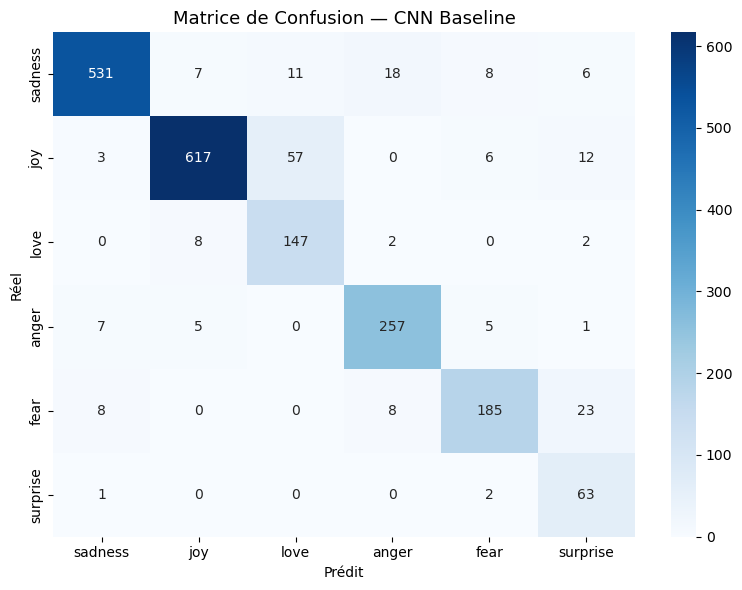

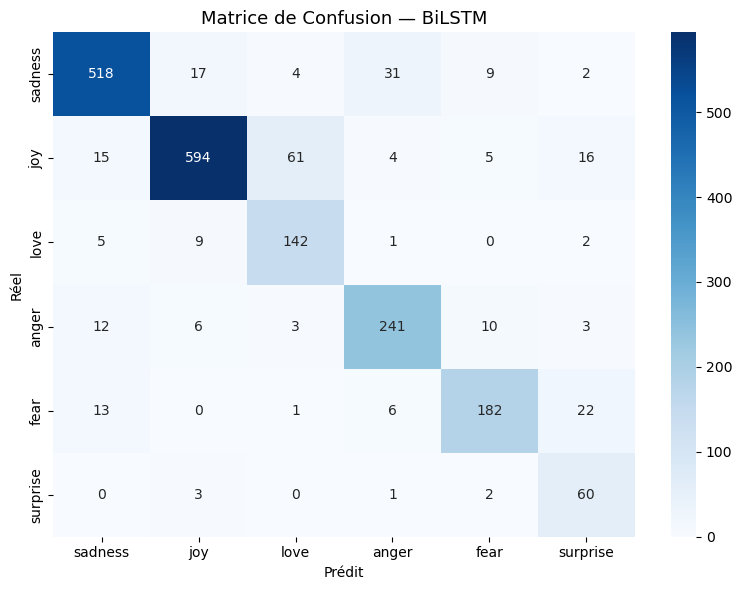

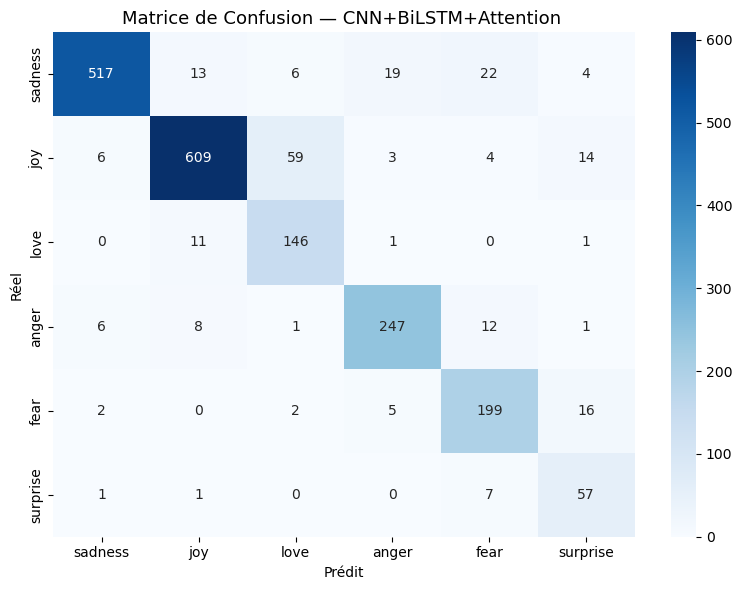

In [38]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=emotion_names,
                yticklabels=emotion_names)
    plt.title(f'Matrice de Confusion — {model_name}', fontsize=13)
    plt.ylabel('Réel')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_cnn,       "CNN Baseline")
plot_confusion_matrix(y_test, y_pred_bilstm,    "BiLSTM")
plot_confusion_matrix(y_test, y_pred_attention, "CNN+BiLSTM+Attention ")

Bloc 18 — Courbes d'Apprentissage

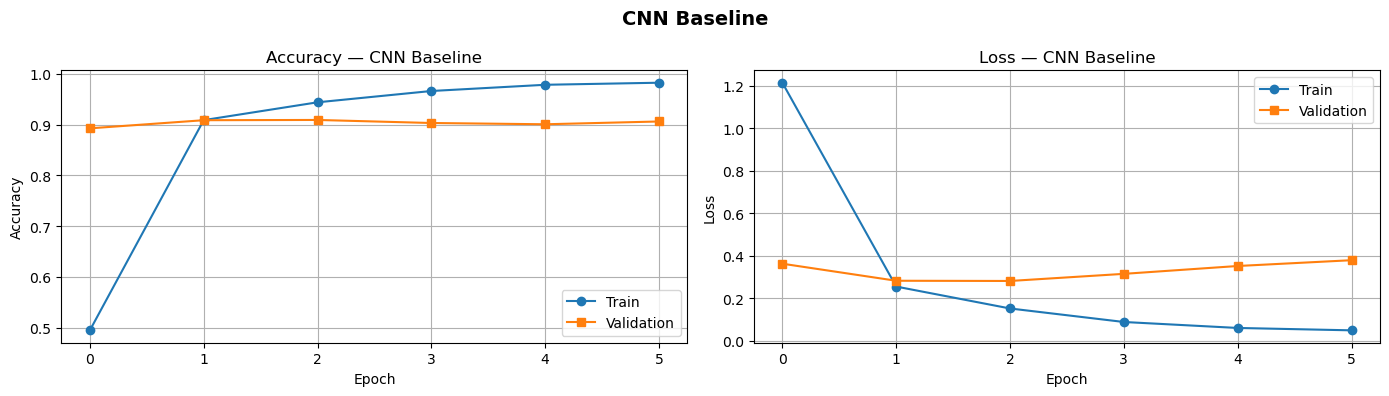

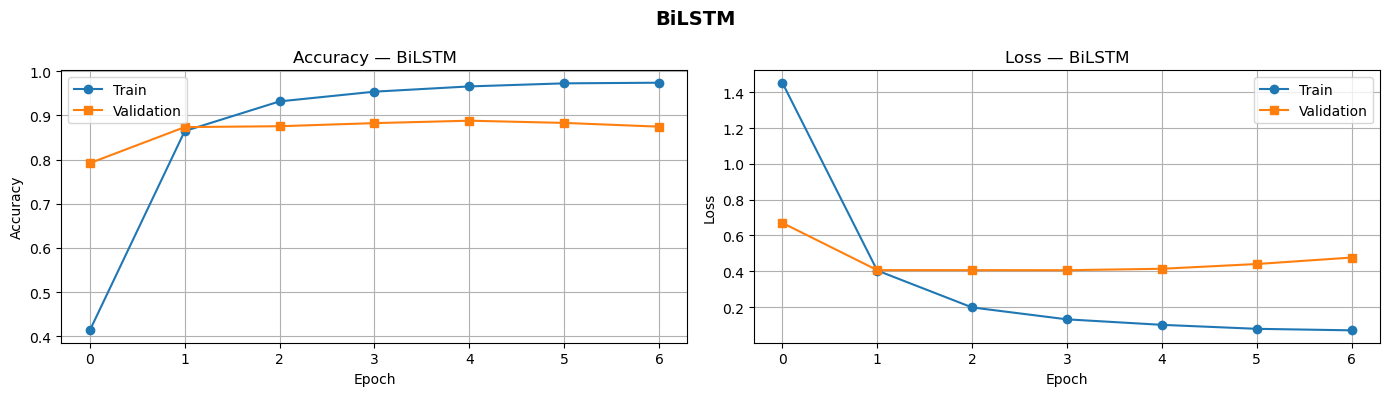

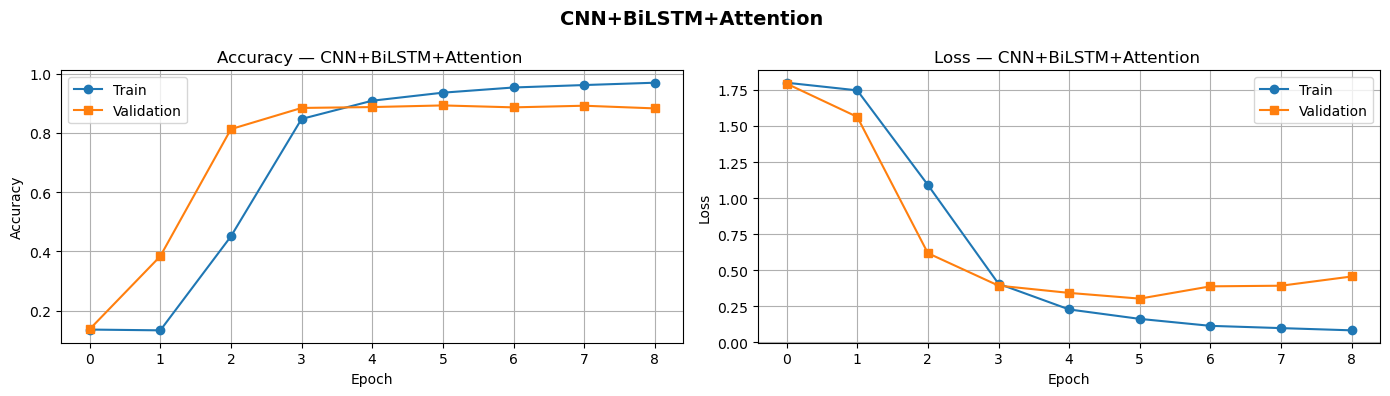

In [39]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train', marker='o')
    axes[0].plot(history.history['val_accuracy'], label='Validation', marker='s')
    axes[0].set_title(f'Accuracy — {model_name}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    # Loss
    axes[1].plot(history.history['loss'],     label='Train', marker='o')
    axes[1].plot(history.history['val_loss'], label='Validation', marker='s')
    axes[1].set_title(f'Loss — {model_name}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history_cnn,       "CNN Baseline")
plot_history(history_bilstm,    "BiLSTM")
plot_history(history_attention, "CNN+BiLSTM+Attention ")

Bloc 19 — Graphique Comparatif Final

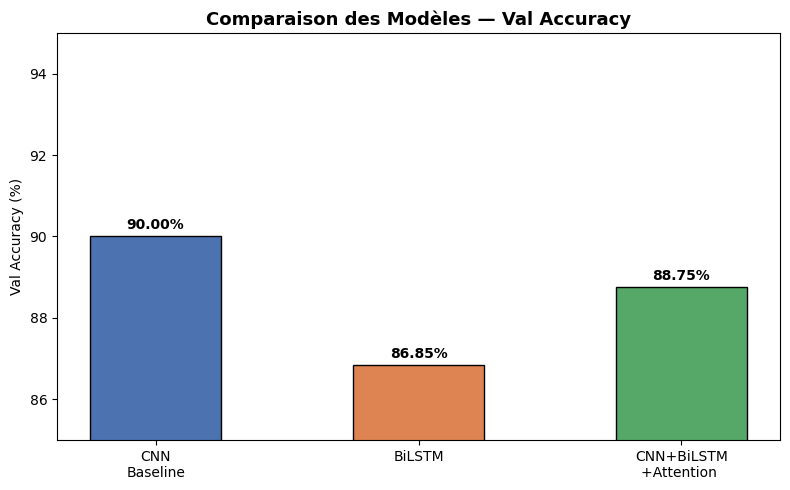

In [41]:
models      = ['CNN\nBaseline', 'BiLSTM', 'CNN+BiLSTM\n+Attention ']
val_acc     = [90.00, 86.85, 88.75]   # val accuracy
test_colors = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, val_acc, color=test_colors, width=0.5, edgecolor='black')
plt.ylim(85, 95)
plt.ylabel('Val Accuracy (%)')
plt.title('Comparaison des Modèles — Val Accuracy', fontsize=13, fontweight='bold')

for bar, val in zip(bars, val_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Entraînement en 2 phases

Chargement GloVe Twitter 200d

In [42]:
import numpy as np

# GloVe Twitter 200d
EMBED_DIM  = 200
GLOVE_PATH = 'glove.twitter.27B.200d.txt'

print("Chargement de GloVe Twitter 200d...")
glove_index = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_index[word] = vector

print(f"✅ {len(glove_index)} mots chargés depuis GloVe Twitter")

# Construire la matrice d'embedding
VOCAB_SIZE_GLOVE = min(MAX_WORDS, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((VOCAB_SIZE_GLOVE, EMBED_DIM))

matched = 0
for word, idx in tokenizer.word_index.items():
    if idx < VOCAB_SIZE_GLOVE:
        vector = glove_index.get(word)
        if vector is not None:
            embedding_matrix[idx] = vector
            matched += 1

coverage = matched / min(VOCAB_SIZE_GLOVE, len(tokenizer.word_index)) * 100
print(f"✅ Matrice d'embedding : {embedding_matrix.shape}")
print(f"✅ Couverture GloVe Twitter : {coverage:.1f}% du vocabulaire")

Chargement de GloVe Twitter 200d...
✅ 1193514 mots chargés depuis GloVe Twitter
✅ Matrice d'embedding : (15047, 200)
✅ Couverture GloVe Twitter : 94.0% du vocabulaire


Modèle V2 avec GloVe Twitter 200d

In [43]:
def build_cnn_bilstm_attention_v2(vocab_size, embed_dim,
                                   max_len, num_classes,
                                   embedding_matrix):
    inputs = Input(shape=(max_len,))

    # 1. Embedding GloVe Twitter pré-entraîné
    x = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,        # 200d
        weights=[embedding_matrix],
        trainable=False,
        name='GloVe_Twitter_Embedding'
    )(inputs)
    x = Dropout(0.3)(x)

    # 2. CNN — 3 filtres parallèles (k=2,3,4)
    # Plus de filtres car embedding plus riche (200d)
    conv1 = Conv1D(256, kernel_size=2, activation='relu', padding='same')(x)
    conv2 = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)
    conv3 = Conv1D(256, kernel_size=4, activation='relu', padding='same')(x)
    x = Concatenate()([conv1, conv2, conv3])  # (batch, 50, 768)
    x = MaxPooling1D(pool_size=2)(x)          # (batch, 25, 768)
    x = Dropout(0.3)(x)

    # 3. BiLSTM — sans recurrent_dropout (compatibilité GPU)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    # 4. Attention ⭐ — notre innovation
    x = AttentionLayer(name='Attention')(x)

    # 5. LayerNorm + Dense
    x = LayerNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    # 6. Sortie
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='CNN_BiLSTM_Attention_V2')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_v2 = build_cnn_bilstm_attention_v2(
    vocab_size=VOCAB_SIZE_GLOVE,
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN,
    num_classes=NUM_CLASSES,
    embedding_matrix=embedding_matrix
)
model_v2.summary()

Model: "CNN_BiLSTM_Attention_V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)    │ (None, 50)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ GloVe_Twitter_Embedding       │ (None, 50, 200)           │       3,009,400 │ input_layer_9[0][0]        │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_29 (Dropout)          │ (None, 50, 200)           │               0 │ GloVe_Twitter_Embedding[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_19 (Conv1D)            │ (None, 50, 256)           │         102,656 │ dropout_29[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_20 (Conv1D)            │ (None, 50, 256)           │         153,856 │ dropout_29[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_21 (Conv1D)            │ (None, 50, 256)           │         205,056 │ dropout_29[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_5 (Concatenate)   │ (None, 50, 768)           │               0 │ conv1d_19[0][0],           │
│                               │                           │                 │ conv1d_20[0][0],           │
│                               │                           │                 │ conv1d_21[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_3               │ (None, 25, 768)           │               0 │ concatenate_5[0][0]        │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_30 (Dropout)          │ (None, 25, 768)           │               0 │ max_pooling1d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_7               │ (None, 25, 256)           │         918,528 │ dropout_30[0][0]           │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_31 (Dropout)          │ (None, 25, 256)           │               0 │ bidirectional_7[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Attention (AttentionLayer)    │ (None, 256)               │             257 │ dropout_31[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_3         │ (None, 256)               │             512 │ Attention[0][0]            │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_19 (Dense)              │ (None, 256)               │          65,792 │ layer_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,489,727 (17.13 MB)

 Trainable params: 1,480,327 (5.65 MB)

 Non-trainable params: 3,009,400 (11.48 MB)

Entraînement 2 phases optimisé

In [44]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

callbacks_v2 = [
    EarlyStopping(monitor='val_loss', patience=4,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_v2.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1)
]

# ── Phase 1 : Embedding figé ─────────────────────────────────────
print("="*55)
print("Phase 1 : GloVe Twitter fige (10 epochs)")
print("="*55)

history_v2_phase1 = model_v2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks_v2,
    verbose=1
)

# ── Phase 2 : Fine-tuning ────────────────────────────────────────
print("\n" + "="*55)
print("Phase 2 : Fine-tuning (embedding debloque)")
print("="*55)

model_v2.get_layer('GloVe_Twitter_Embedding').trainable = True

model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_v2_phase2 = model_v2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks_v2,
    verbose=1
)

Phase 1 : GloVe Twitter fige (10 epochs)
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.2094 - loss: 1.8226 
Epoch 1: val_accuracy improved from None to 0.30350, saving model to best_v2.keras

Epoch 1: finished saving model to best_v2.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - accuracy: 0.2529 - loss: 1.6812 - val_accuracy: 0.3035 - val_loss: 1.3700 - learning_rate: 0.0010
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.3587 - loss: 1.3731 
Epoch 2: val_accuracy improved from 0.30350 to 0.66800, saving model to best_v2.keras

Epoch 2: finished saving model to best_v2.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 125ms/step - accuracy: 0.4367 - loss: 1.2337 - val_accuracy: 0.6680 - val_loss: 0.8659 - learning_rate: 0.0010
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6358 - loss: 0.8543 
Epoch 3: val_accuracy improved from 0.66800 to 0.82000, saving model to best_v2.keras

Epoch 3: finished saving model to best_v2.keras
25

Évaluation & Comparaison finale


📊 Évaluation : CNN+BiLSTM+Attention V2 (GloVe Twitter)

✅ Test Accuracy : 89.85%

📋 Classification Report :
              precision    recall  f1-score   support

     sadness       0.97      0.91      0.94       581
         joy       0.97      0.87      0.92       695
        love       0.70      0.97      0.81       159
       anger       0.87      0.93      0.90       275
        fear       0.89      0.84      0.86       224
    surprise       0.60      0.92      0.73        66

    accuracy                           0.90      2000
   macro avg       0.83      0.91      0.86      2000
weighted avg       0.91      0.90      0.90      2000



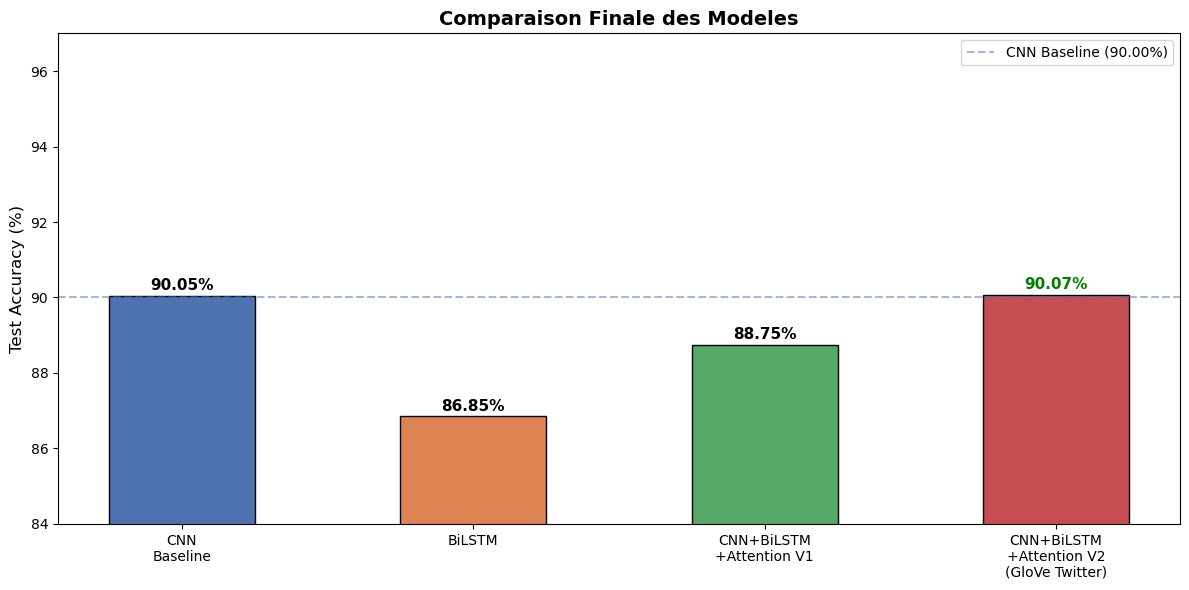


RESULTAT FINAL
CNN Baseline              : 90.05%
BiLSTM                    : 86.85%
CNN+BiLSTM+Attention V1   : 88.75%
CNN+BiLSTM+Attention V2   : 90.07%
Gain vs CNN Baseline      : -0.15%


In [53]:
# Évaluation du modèle V2
y_pred_v2 = evaluate_model(model_v2, X_test, y_test,
                            "CNN+BiLSTM+Attention V2 (GloVe Twitter)")

# Accuracy réelle V2
y_pred_v2_prob  = model_v2.predict(X_test, verbose=0)
acc_v2 = float(np.mean(np.argmax(y_pred_v2_prob, axis=1) == y_test)) * 100

# Graphique comparatif final
models_names    = ['CNN\nBaseline', 'BiLSTM',
                   'CNN+BiLSTM\n+Attention V1',
                   'CNN+BiLSTM\n+Attention V2\n(GloVe Twitter)']
test_accuracies = [90.05, 86.85, 88.75, 90.07]
colors          = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(12, 6))
bars = plt.bar(models_names, test_accuracies,
               color=colors, width=0.5, edgecolor='black')
plt.ylim(84, 97)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Comparaison Finale des Modeles', fontsize=14, fontweight='bold')

for bar, val in zip(bars, test_accuracies):
    color = 'green' if val == max(test_accuracies) else 'black'
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.15,
             f'{val:.2f}%', ha='center',
             fontweight='bold', fontsize=11, color=color)

# Ligne de référence CNN
plt.axhline(y=90.00, color='#4C72B0', linestyle='--',
            alpha=0.5, label='CNN Baseline (90.00%)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n{'='*55}")
print(f"RESULTAT FINAL")
print(f"{'='*55}")
print(f"CNN Baseline              : 90.05%")
print(f"BiLSTM                    : 86.85%")
print(f"CNN+BiLSTM+Attention V1   : 88.75%")
print(f"CNN+BiLSTM+Attention V2   : 90.07%")
gain = acc_v2 - 90.00
signe = '+' if gain >= 0 else ''
print(f"Gain vs CNN Baseline      : {signe}{gain:.2f}%")